# **1. Environment Setup & Dependency Installation**

Installs the necessary quantum computing frameworks and machine learning libraries required for hybrid CNN-Quantum execution on IBM hardware.

In [1]:
# Install PennyLane for quantum-classical machine learning integration
!pip install pennylane --quiet

# Install the PennyLane-Qiskit plugin to enable communication with IBM backends
!pip install pennylane-qiskit --quiet

# Install Qiskit Runtime Service for managing real quantum hardware jobs
!pip install qiskit-ibm-runtime --quiet

# Import standard libraries for data handling, deep learning, and plotting
import torch
import torch.nn as nn
import pennylane as qml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit_ibm_runtime import QiskitRuntimeService
from google.colab import userdata, drive
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Set the processing device to GPU if available, otherwise use CPU
device_pc = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Processing on: {device_pc}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4

# **2. IBM Quantum Authentication & Hardware Selection**

Authenticates the session with IBM Quantum using the account token and automatically selects the least busy operational quantum processor to minimize wait times.

In [2]:
# Retrieve the IBM Quantum token stored in Colab's secret keys
token = userdata.get('ibm_token')

# Initialize the Qiskit Runtime Service with the provided token
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token)

# Identify the least busy operational quantum computer (excluding simulators)
backend = service.least_busy(simulator=False, operational=True)

# Save the backend name for future reference in logs and plots
backend_name = backend.name

# Output the selection to confirm successful connection
print(f"Connected to IBM Quantum. Targeted hardware: {backend_name} ({backend.num_qubits} qubits)")

qiskit_runtime_service._discover_account:WARNING:2026-04-10 11:54:56,828: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-10 11:54:59,728: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-10 11:55:00,390: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-10 11:55:02,143: Using instance: open-instance, plan: open


Connected to IBM Quantum. Targeted hardware: ibm_fez (156 qubits)


# **3. Data Loading & Test Set Preparation**

Loads the pre-processed balanced dataset, and prepares the test subset to ensure data consistency with the training phase.

In [3]:

# Load the balanced dataset into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Padeborn_Dataset/train_cnn_quantum.csv')

# Separate features (vibration signals) and target labels
X = df.drop('label', axis=1).values
y = df['label'].values

# Split data using the same random seed (42) to isolate the exact test set used in training
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert NumPy arrays to PyTorch tensors with correct dimensions and types
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).view(-1, 1, 1024)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create a DataLoader for organized batch processing during inference
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data prepared: {len(X_test)} samples ready for validation.")

Data prepared: 4000 samples ready for validation.


# **4. Hybrid Model Architecture & Weight Loading**

Defines the unified 1D CNN-Quantum architecture and loads the pre-trained weights to prepare the model for real-hardware inference.

In [4]:
# Define hyper-parameters for the quantum circuit to match the training setup
n_qubits = 4
n_layers = 6

# Initialize a local device for architecture definition before remote execution
dev_local = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_local, interface="torch")
def quantum_circuit(inputs, weights):
    for i in range(weights.shape[0]):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class CNNQuantumModel(nn.Module):
    def __init__(self, n_layers=6):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=64, stride=4),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=16, stride=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc_compress = nn.Linear(32, 4)
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.fc_final = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = self.fc_compress(x)
        x = torch.tanh(x) * (np.pi / 2) + (np.pi / 2)
        x = self.quantum_layer(x)
        x = self.fc_final(x)
        return torch.log_softmax(x, dim=1)

# Initialize the model and load weights from the .pth file in Google Drive
model = CNNQuantumModel(n_layers=n_layers).to(device_pc)
checkpoint = torch.load('/content/drive/MyDrive/Padeborn_Dataset/cnn_quantum_model.pth', map_location=device_pc)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Model architecture defined and pre-trained weights loaded successfully.")

Model architecture defined and pre-trained weights loaded successfully.


# **5. Quantum Circuit Configuration (Remote Device)**

Configures the remote PennyLane device to communicate with the IBM Quantum backend and defines the quantum node for real-hardware execution.

In [5]:
# Initialize the PennyLane device for remote execution on the selected IBM hardware
dev_ibm = qml.device('qiskit.remote', wires=n_qubits, backend=backend)

# Define the QNode for IBM hardware execution, maintaining Torch compatibility
@qml.qnode(dev_ibm, interface="torch")
def quantum_circuit_ibm(inputs, weights):
    # Iterate through each layer of the variational quantum circuit
    for i in range(weights.shape[0]):
        # Upload classical features into the quantum state via Angle Embedding
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        # Apply the trained strongly entangling layers for feature processing
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(n_qubits))
    # Measure the expectation values of the Pauli-Z operator for all qubits
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

print(f"Remote quantum node successfully configured for: {backend_name}")

Remote quantum node successfully configured for: ibm_fez


# **6. Real-Hardware Inference Execution (Job Submission)**

Submits processed features to the IBM Quantum backend for real-time inference and compares the results with the ground-truth labels.
Ensures all tensors are synchronized on the correct device for final classification.

In [7]:
# Select 10 random samples from the test set for real-hardware validation
indices = np.random.choice(len(X_test), 10, replace=False)
subset_x = X_test[indices]
subset_y = y_test[indices]

y_real_labels = []
y_predicted_labels = []

print(f"Submitting 10 jobs to {backend_name}...")

with torch.no_grad():
    for i, (signal, label) in enumerate(zip(subset_x, subset_y)):
        # 1. Classical Feature Extraction (Local GPU/CPU)
        signal_tensor = torch.tensor(signal, dtype=torch.float32).view(1, 1, 1024).to(device_pc)
        features = model.cnn(signal_tensor)
        features = model.fc_compress(features.view(1, -1))
        features = torch.tanh(features) * (np.pi / 2) + (np.pi / 2)

        # 2. Quantum Processing (Remote IBM Hardware)
        q_out = quantum_circuit_ibm(features[0], model.quantum_layer.weights)

        # 3. Final Classification (Ensuring device synchronization)
        quantum_tensor = torch.tensor(q_out, dtype=torch.float32).view(1, -1).to(device_pc)
        final_out = model.fc_final(quantum_tensor)
        prediction = torch.argmax(final_out).item()

        y_real_labels.append(int(label))
        y_predicted_labels.append(prediction)

        status = "Correct" if prediction == label else "Wrong"
        print(f"Sample {i+1}: {status} (Target: {int(label)}, Prediction: {prediction})")

real_hw_acc = np.mean(np.array(y_real_labels) == np.array(y_predicted_labels)) * 100
print(f"\nFinal Accuracy on {backend_name}: {real_hw_acc:.2f}%")

Submitting 10 jobs to ibm_fez...
Sample 1: Correct (Target: 3, Prediction: 3)
Sample 2: Correct (Target: 2, Prediction: 2)
Sample 3: Correct (Target: 3, Prediction: 3)
Sample 4: Wrong (Target: 2, Prediction: 1)
Sample 5: Correct (Target: 1, Prediction: 1)
Sample 6: Correct (Target: 0, Prediction: 0)
Sample 7: Correct (Target: 3, Prediction: 3)
Sample 8: Correct (Target: 2, Prediction: 2)
Sample 9: Correct (Target: 3, Prediction: 3)
Sample 10: Correct (Target: 3, Prediction: 3)

Final Accuracy on ibm_fez: 90.00%


# **7. Performance Metrics: Confusion Matrix & Accuracy**

Visualizes the classification results on real quantum hardware using a confusion matrix and compares the final accuracy against the simulation baseline.

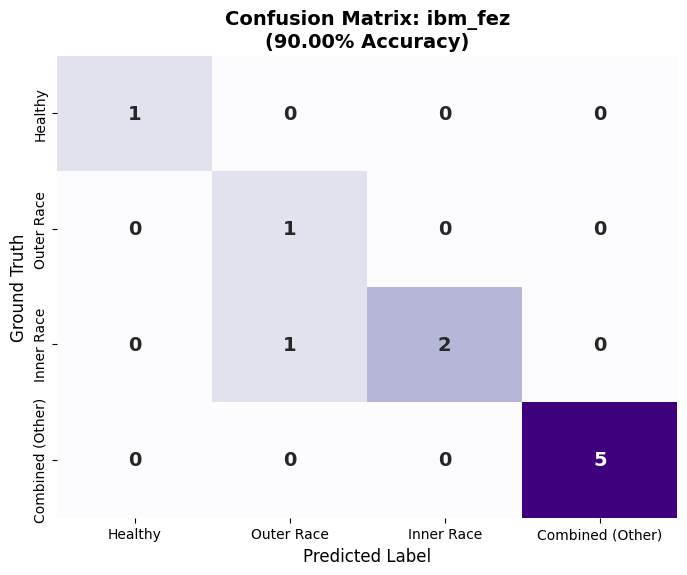

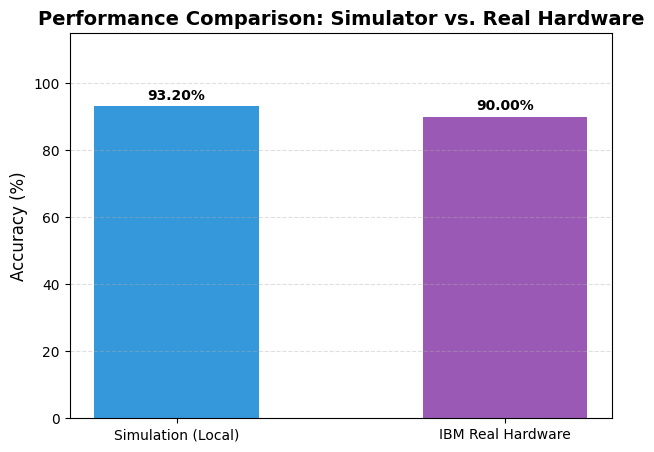

In [9]:
# Import metrics and visualization tools
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the descriptive labels for the diagnostic classes
class_names = ['Healthy', 'Outer Race', 'Inner Race', 'Combined (Other)']

# Generate the confusion matrix from the IBM hardware results
cm = confusion_matrix(y_real_labels, y_predicted_labels, labels=[0, 1, 2, 3])

# Create a heatmap to visualize the classification performance
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names, cbar=False, annot_kws={"size": 14, "weight": "bold"})
plt.title(f'Confusion Matrix: {backend_name}\n({real_hw_acc:.2f}% Accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# Set the accuracy values for comparison (Simulation vs. Real Hardware)
simulation_accuracy = 93.20
real_hardware_accuracy = real_hw_acc

# Plot a bar chart comparing the simulation performance with real hardware execution
plt.figure(figsize=(7, 5))
labels = ['Simulation (Local)', 'IBM Real Hardware']
accuracies = [simulation_accuracy, real_hardware_accuracy]
bars = plt.bar(labels, accuracies, color=['#3498db', '#9b59b6'], width=0.5)

# Add title and labels for the performance chart
plt.ylim(0, 115)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Performance Comparison: Simulator vs. Real Hardware', fontsize=14, fontweight='bold')

# Annotate each bar with its respective accuracy percentage
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# **8. Quantum Feature Visualization (Hilbert Space Fingerprints)**

Generates radar charts to visualize the unique quantum signatures of each diagnostic class within the Hilbert Space, demonstrating how the VQC distinguishes between different fault types.

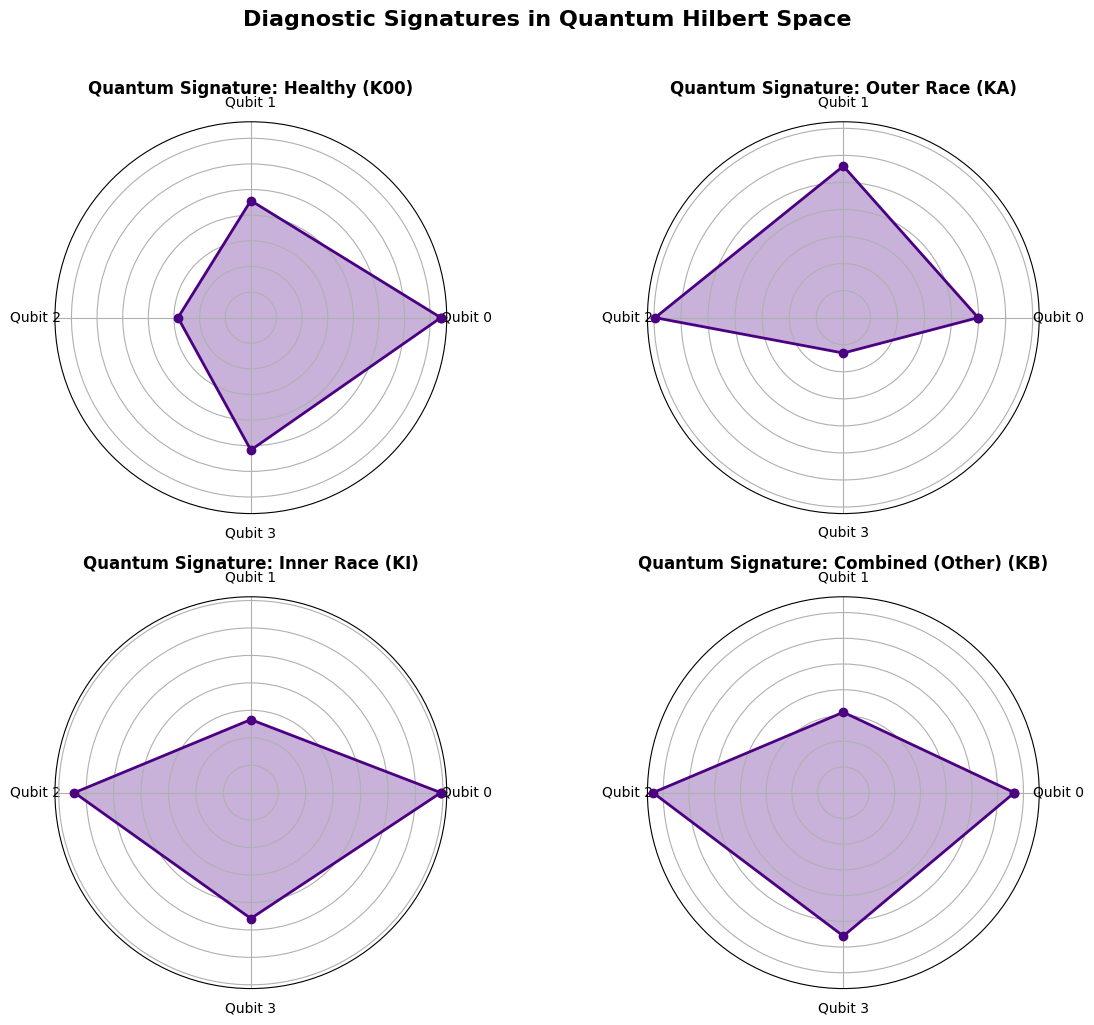

In [10]:
def plot_quantum_signatures(model, loader):
    model.eval()
    all_q_outs = []
    labels = []
    labels_map = {0: 'Healthy (K00)', 1: 'Outer Race (KA)', 2: 'Inner Race (KI)', 3: 'Combined (Other) (KB)'}

    with torch.no_grad():
        for signals, lbls in loader:
            # Local simulation to extract the quantum signatures
            feat = model.cnn(signals.to(device_pc, dtype=torch.float32))
            feat = model.fc_compress(feat.view(signals.size(0), -1))
            feat = torch.tanh(feat) * (np.pi / 2) + (np.pi / 2)

            # Capture the expectation values from the quantum layer
            q_out = model.quantum_layer(feat)

            all_q_outs.append(q_out.cpu().numpy())
            labels.extend(lbls.numpy())

            # Stop once we have enough samples for a clear visualization
            if len(set(labels)) == 4 and len(labels) > 100:
                break

    all_q_outs = np.vstack(all_q_outs)
    categories = ['Qubit 0', 'Qubit 1', 'Qubit 2', 'Qubit 3']
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(12, 10))
    for i in range(4):
        try:
            idx = labels.index(i)
            values = all_q_outs[idx].tolist()
            # Normalize Pauli-Z expectation values [-1, 1] to [0, 1] for the radar plot
            norm_values = [(v + 1) / 2 for v in values]
            norm_values += norm_values[:1]

            ax = plt.subplot(2, 2, i+1, polar=True)
            ax.fill(angles, norm_values, color='indigo', alpha=0.3)
            ax.plot(angles, norm_values, color='indigo', linewidth=2, marker='o')
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(categories, fontsize=10)
            ax.set_yticklabels([])
            plt.title(f"Quantum Signature: {labels_map[i]}", fontsize=12, fontweight='bold', pad=20)
        except ValueError:
            continue

    plt.suptitle("Diagnostic Signatures in Quantum Hilbert Space", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Run the visualization using the test_loader defined in Section 3
plot_quantum_signatures(model, test_loader)

# **9. Raw Signal Analysis: Diagnostic Gallery**

Visualizes the raw vibration signals alongside their ground-truth labels and quantum-enhanced predictions to provide a physical context for the diagnostic results.

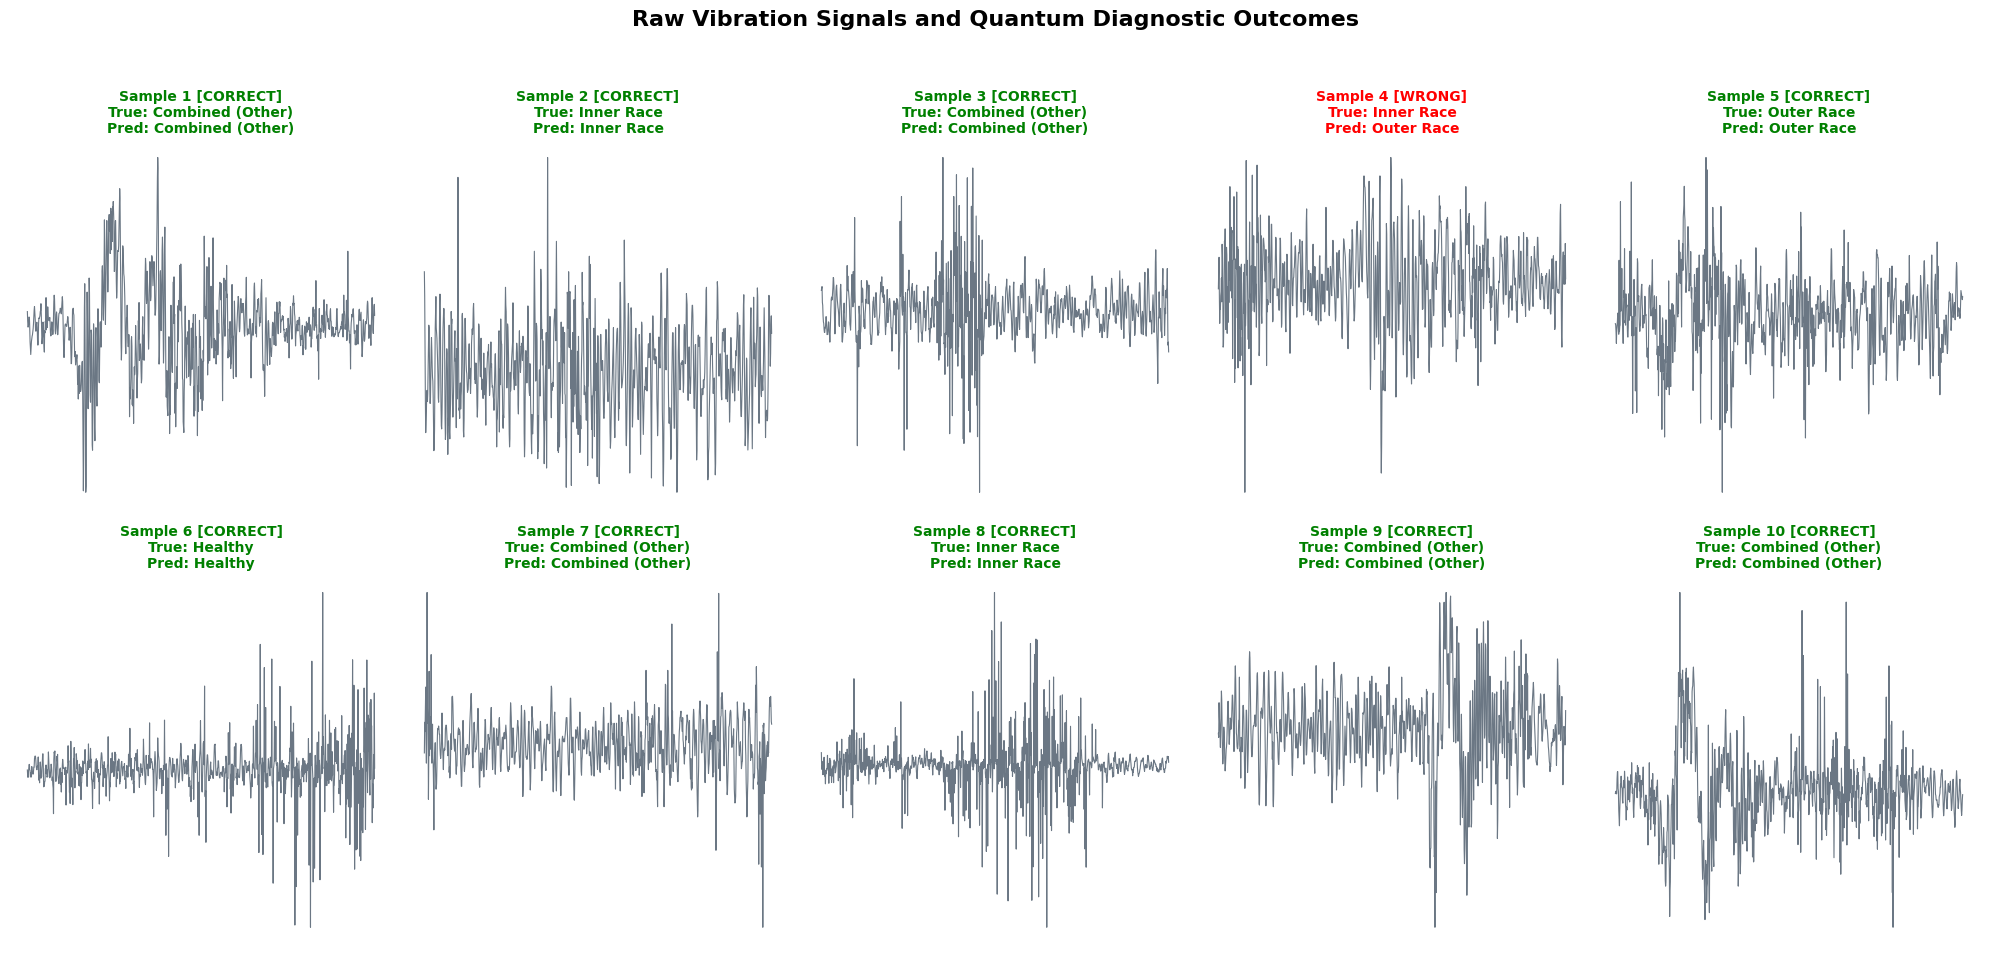

In [12]:
labels_map = {0: 'Healthy', 1: 'Outer Race', 2: 'Inner Race', 3: 'Combined (Other)'}

plt.figure(figsize=(20, 10))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.plot(subset_x[i], color='#2c3e50', alpha=0.7, linewidth=0.8)

    is_correct = y_real_labels[i] == y_predicted_labels[i]
    title_color = 'green' if is_correct else 'red'
    status_text = "[CORRECT]" if is_correct else "[WRONG]"

    plt.title(f"Sample {i+1} {status_text}\nTrue: {labels_map[y_real_labels[i]]}\nPred: {labels_map[y_predicted_labels[i]]}",
              color=title_color, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle("Raw Vibration Signals and Quantum Diagnostic Outcomes", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **10. Advanced Quantum Diagnostics & Model Interpretability**

The internal mechanisms of the Hybrid Model are explored in this section. Through the inspection of quantum state probabilities, learned parameters, and feature clustering, transparency is provided regarding how the Variational Quantum Circuit (VQC) interprets mechanical vibration patterns.

### **10.1. Quantum State Probabilities (Computational Basis)**

This visualization presents the wave function's collapse into the 16 possible states of the 4-qubit system. It illustrates the distribution of probability across the computational basis for a specific fault sample, revealing the unique "quantum fingerprint" generated by the VQC before the final classification stages.

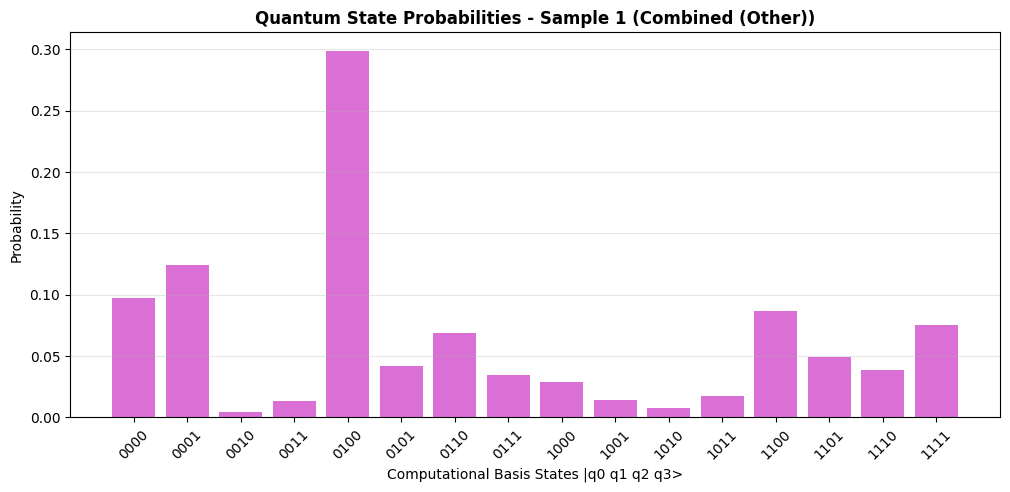

In [27]:
# State Probability Distribution: Visualizing the superposition for a specific sample
idx = 0
signal = torch.tensor(subset_x[idx], dtype=torch.float32).view(1, 1, 1024).to(device_pc)

with torch.no_grad():
    feat = model.cnn(signal)
    feat = model.fc_compress(feat.view(1, -1))
    feat = torch.tanh(feat) * (np.pi / 2) + (np.pi / 2)

@qml.qnode(dev_local, interface="torch")
def get_probs(inputs, weights):
    for i in range(weights.shape[0]):
        qml.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights[i:i+1], wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

probs = get_probs(feat[0], model.quantum_layer.weights).detach().cpu().numpy()
states = [format(i, '04b') for i in range(16)]

plt.figure(figsize=(12, 5))
plt.bar(states, probs, color='orchid')
plt.xticks(rotation=45)
plt.title(f"Quantum State Probabilities - Sample {idx+1} ({labels_map[y_real_labels[idx]]})", fontweight='bold')
plt.ylabel("Probability")
plt.xlabel("Computational Basis States |q0 q1 q2 q3>")
plt.grid(axis='y', alpha=0.3)
plt.show()

### **10.2. Variational Parameter Analysis (Weight Heatmap)**

The VQC architecture consists of 6 entangling layers. This heatmap illustrates the absolute intensity of the learned variational parameters. Higher values indicate specific qubits and layers that became more sensitive to vibration features during the training process, effectively identifying the "learned attention" within the quantum processor.

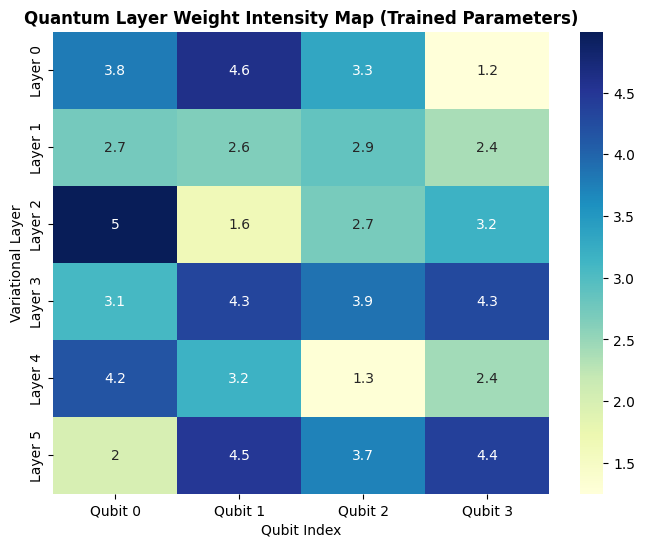

In [28]:
# Quantum Weight Intensity Map
weights = model.quantum_layer.weights.detach().cpu().numpy()
weight_intensity = np.mean(np.abs(weights), axis=2)

plt.figure(figsize=(8, 6))
sns.heatmap(weight_intensity, annot=True, cmap='YlGnBu',
            xticklabels=[f'Qubit {i}' for i in range(4)],
            yticklabels=[f'Layer {i}' for i in range(6)])
plt.title("Quantum Layer Weight Intensity Map (Trained Parameters)", fontweight='bold')
plt.xlabel("Qubit Index")
plt.ylabel("Variational Layer")
plt.show()

### **10.3. Hilbert Space Projection (PCA Clustering)**

To verify the quantum layer's effectiveness in distinguishing between fault types, 4-dimensional quantum feature vectors are extracted and projected into a 2D plane using Principal Component Analysis (PCA). The emergence of clear clusters demonstrates that the VQC has successfully mapped distinct mechanical conditions into separate regions of the Hilbert Space.

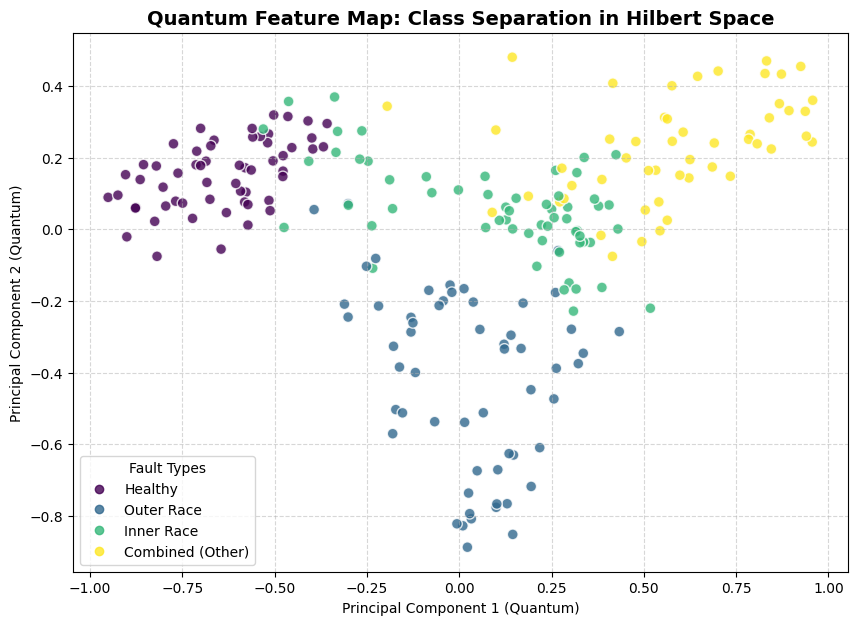

In [34]:
from sklearn.decomposition import PCA

# Hilbert Space Projection: Visualizing how the Quantum Layer separates classes
all_features = []
all_labels = []

model.eval()
with torch.no_grad():
    for signals, lbls in test_loader:
        # Classical preprocessing
        feat = model.cnn(signals.to(device_pc, dtype=torch.float32))
        feat = model.fc_compress(feat.view(signals.size(0), -1))
        feat = torch.tanh(feat) * (np.pi / 2) + (np.pi / 2)

        # Extract the 4-dimensional quantum feature vector (Pauli-Z expectations)
        q_out = model.quantum_layer(feat)
        all_features.append(q_out.detach().cpu().numpy())
        all_labels.extend(lbls.numpy())
        if len(all_labels) > 200: break # Use enough samples for a clear map

# Reduce the 4D quantum output to 2D for visualization
pca = PCA(n_components=2)
features_2d = pca.fit_transform(np.vstack(all_features))

# Plot the clusters in "Quantum Space"
plt.figure(figsize=(10, 7))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=all_labels, cmap='viridis', s=60, alpha=0.8, edgecolors='white')
plt.title("Quantum Feature Map: Class Separation in Hilbert Space", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1 (Quantum)", fontsize=10)
plt.ylabel("Principal Component 2 (Quantum)", fontsize=10)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Fault Types")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **10.4. Variational Quantum Circuit (VQC) Architecture**

The structural design of the quantum layer is represented in this schematic. It details the AngleEmbedding method for classical-to-quantum data mapping and the sequence of StronglyEntanglingLayers (comprising rotations and CNOT gates). This diagram serves as the technical blueprint for the implementation executed on IBM hardware.

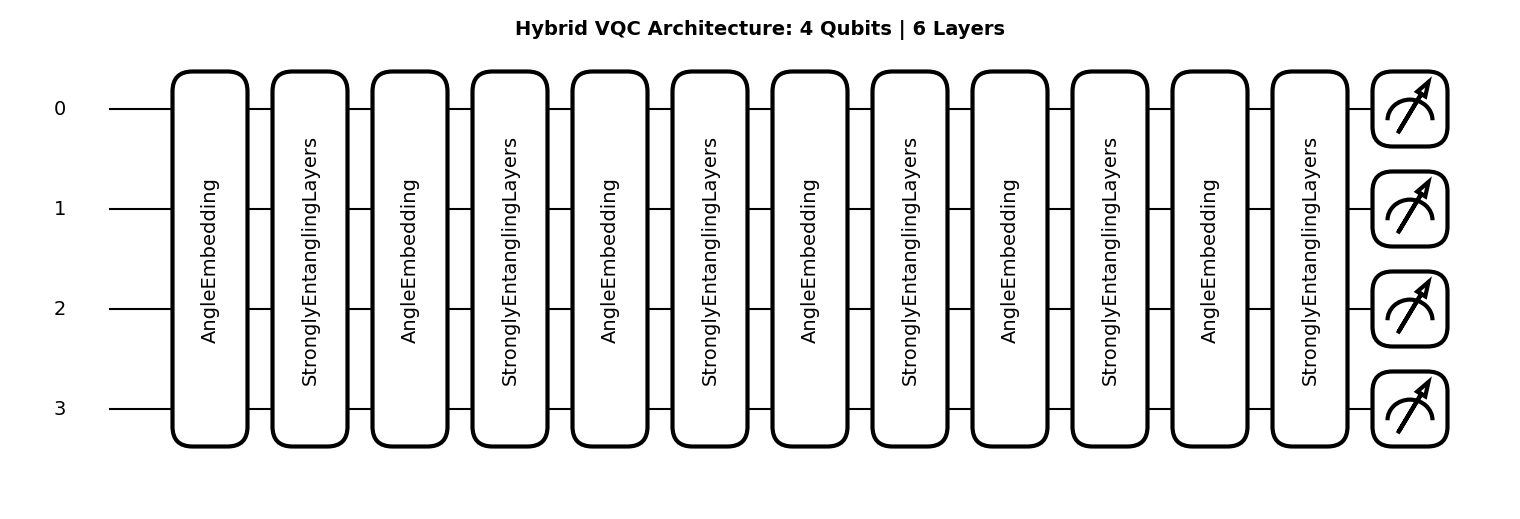

In [35]:
# Circuit Drawing: Showing the gates and qubits architecture
# Pick a dummy input to render the structure
dummy_input = torch.tensor([np.pi/4] * n_qubits, dtype=torch.float32)
dummy_weights = model.quantum_layer.weights.detach()

# Use PennyLane's drawing utility to create a professional diagram
fig, ax = qml.draw_mpl(quantum_circuit)(dummy_input, dummy_weights)
fig.suptitle("Hybrid VQC Architecture: 4 Qubits | 6 Layers", fontsize=14, fontweight='bold')
plt.show()